# 07 - Credit Scorecard and WoE

## Credit Risk Modelling Using Logistic Regression

This notebook builds a conventional Weight of Evidence (WoE) logistic scorecard from the same eight predictors used by the baseline model. It defines default as **Bad (Y=1)** and non-default as **Good (Y=0)** throughout.

All bin edges, WoE values, and model coefficients are learned from the seed 47 training partition. The holdout is reserved for one final descriptive evaluation. The baseline from Notebook 04 and selected advanced model from Notebook 06 remain the benchmarks.


## 1. Define good and bad

$$
Bad=Y=1,\qquad Good=Y=0.
$$

With this convention, a bin with more Good than Bad relative to the population has positive WoE under the definition below. Its scorecard coefficient is estimated from the data, so the direction of the final PD effect is determined by the fitted WoE logistic model.


In [1]:
import os
import sys
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

sys.path.insert(0, "../src")
from model import prepare_data, split_data, predict_pd as base_pred
from advanced_model import predict_model
from evaluation import discrimination_metrics, calibration_table
from scorecard import (
    fit_bins, fit_woe, make_pack, score_scale, score_rows,
    point_table, score_points, pd_from_score,
)

clean = pd.read_csv("../data/processed/cleaned_data.csv")
feat, target = prepare_data(clean)
with open("../models/logistic_regression.pkl", "rb") as model_file:
    base_pack = pickle.load(model_file)
with open("../models/advanced_pd_model.pkl", "rb") as model_file:
    adv_pack = pickle.load(model_file)

train_feat, hold_feat, train_y, hold_y = split_data(
    feat, target, base_pack["seed"]
)
train_x = train_feat.copy()
print(f"Seed: {base_pack['seed']}")
print(f"Training borrowers: {len(train_y):,}")
print(f"Holdout borrowers: {len(hold_y):,}")


Seed: 47
Training borrowers: 101,893
Holdout borrowers: 43,669


In [2]:
class_tab = pd.DataFrame({
    "class": ["Good (Y=0)", "Bad (Y=1)"],
    "borrowers": [int(train_y.eq(0).sum()), int(train_y.eq(1).sum())],
    "share": [float(train_y.eq(0).mean()), float(train_y.eq(1).mean())],
})
display(class_tab.round(4))


,class,borrowers,share
0,Good (Y=0),95011,0.9325
1,Bad (Y=1),6882,0.0675


## 2. Bin selected predictors

Continuous predictors use up to five quantile bins with cut points estimated from training predictors only. Delinquency count, real-estate-loan count, and dependent count use fixed integer bands that keep zero and low counts distinct and combine the upper tail. Quantile ties are collapsed, so some predictors may have fewer than five bins.

Binning does not use the target. We retain non-monotonic risk patterns rather than forcing a monotonic trend. Each reported bin is checked for its borrower count; no holdout data contribute to the cut points or bin statistics.


In [3]:
train_x = train_x.rename(columns={
    "RevolvingUtilizationOfUnsecuredLines": "util",
    "DebtRatio": "debt",
    "LogMonthlyIncome": "income",
    "TotalDelinquencies": "delinq",
    "NumberOfOpenCreditLinesAndLoans": "open",
    "NumberRealEstateLoansOrLines": "estate",
    "NumberOfDependents": "dependents",
})

bin_pack, train_woe, bin_tab, iv_tab = fit_bins(
    train_x, train_y, n_bins=5, alpha=0.5
)
min_n = int(bin_tab["borrowers"].min())
min_pct = 100 * min_n / len(train_y)
print(f"WoE smoothing per class/bin: {bin_pack['alpha']}")
print(f"Number of fitted bins: {len(bin_tab)}")
print(f"Smallest bin: {min_n:,} borrowers ({min_pct:.2f}% of training data)")
zero_n = int((bin_tab["good"].eq(0) | bin_tab["bad"].eq(0)).sum())
print(f"Bins with a zero Good or Bad count before smoothing: {zero_n}")
print(f"Largest absolute WoE after smoothing: {bin_tab['woe'].abs().max():.3f}")
print(f"All training rows received a WoE value: {train_woe.notna().all().all()}")

var_lab = {
    "age": "Age",
    "util": "Revolving utilization",
    "debt": "Debt ratio",
    "income": "Log monthly income",
    "delinq": "Total delinquencies",
    "open": "Open credit lines",
    "estate": "Real estate loans",
    "dependents": "Dependents",
}
show_bins = bin_tab.copy()
show_bins["variable"] = show_bins["variable"].map(var_lab)
show_bins["bin"] = show_bins["bin"].astype(str)
display(show_bins[[
    "variable", "bin", "borrowers", "good", "bad",
    "dist_good", "dist_bad", "bad_rate", "woe",
]].round(4))


WoE smoothing per class/bin: 0.5
Number of fitted bins: 38
Smallest bin: 1,971 borrowers (1.93% of training data)
Bins with a zero Good or Bad count before smoothing: 0
Largest absolute WoE after smoothing: 2.714
All training rows received a WoE value: True


,variable,bin,borrowers,good,bad,dist_good,dist_bad,bad_rate,woe
0,Age,"[-inf, 39.0)",19634,17521,2113,0.1844,0.3070,0.1076,-0.5097
1,Age,"[39.0, 48.0)",20517,18748,1769,0.1973,0.2570,0.0862,-0.2643
2,Age,"[48.0, 56.0)",20073,18573,1500,0.1955,0.2180,0.0747,-0.1088
3,Age,"[56.0, 65.0)",21091,20121,970,0.2118,0.1410,0.0460,0.4070
4,Age,"[65.0, inf)",20578,20048,530,0.2110,0.0771,0.0258,1.0073
5,Revolving utilization,"[-inf, 0.0201)",20379,19983,396,0.2103,0.0576,0.0194,1.2952
6,Revolving utilization,"[0.0201, 0.086)",20378,20028,350,0.2108,0.0509,0.0172,1.4208
7,Revolving utilization,"[0.086, 0.276)",20379,19795,584,0.2083,0.0849,0.0287,0.8977
8,Revolving utilization,"[0.276, 0.698)",20378,18914,1464,0.1991,0.2127,0.0718,-0.0663
9,Revolving utilization,"[0.698, inf)",20379,16291,4088,0.1715,0.5939,0.2006,-1.2423


,variable,risk_pattern,bins
0,Age,Decreasing,5
1,Revolving utilization,Non-monotonic,5
2,Debt ratio,Non-monotonic,5
3,Log monthly income,Decreasing,5
4,Total delinquencies,Increasing,5
5,Open credit lines,Non-monotonic,5
6,Real estate loans,Non-monotonic,4
7,Dependents,Increasing,4


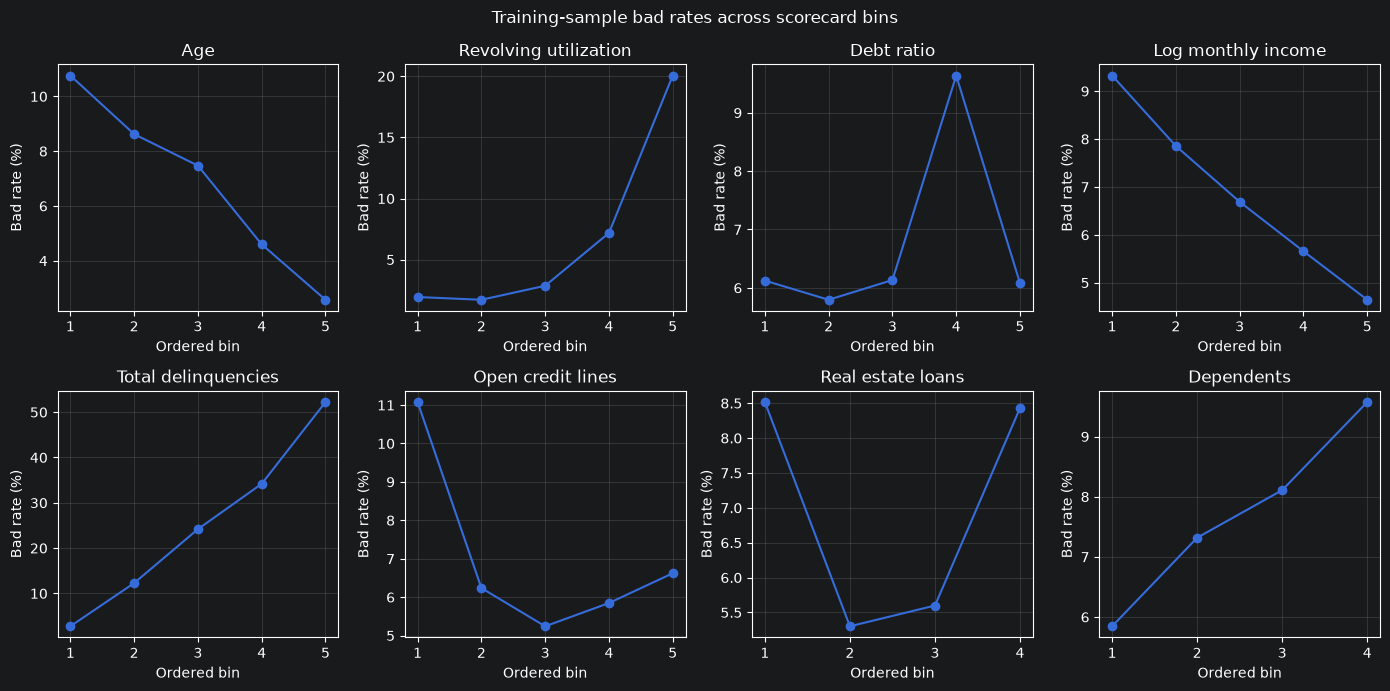

Saved bin-risk chart to ../reports/figures/07_scorecard_bad_rates.png


In [4]:
mono_rows = []
for name, part in bin_tab.groupby("variable", sort=False):
    rate = part.sort_values("bin")["bad_rate"].to_numpy()
    delta = np.diff(rate)
    is_up = bool((delta >= 0).all())
    is_down = bool((delta <= 0).all())
    direction = "Increasing" if is_up else "Decreasing" if is_down else "Non-monotonic"
    mono_rows.append({
        "variable": var_lab[name],
        "risk_pattern": direction,
        "bins": len(rate),
    })
mono_tab = pd.DataFrame(mono_rows)
display(mono_tab)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, name in zip(axes.ravel(), bin_pack["features"]):
    part = bin_tab.loc[bin_tab["variable"].eq(name)].sort_values("bin")
    ax.plot(np.arange(1, len(part) + 1), part["bad_rate"] * 100, marker="o")
    ax.set_title(var_lab[name])
    ax.set_xlabel("Ordered bin")
    ax.set_ylabel("Bad rate (%)")
    ax.grid(alpha=0.25)
fig.suptitle("Training-sample bad rates across scorecard bins")
fig.tight_layout()
FIG_PATH = "../reports/figures/07_scorecard_bad_rates.png"
fig.savefig(FIG_PATH, dpi=160, bbox_inches="tight")
plt.show()
print(f"Saved bin-risk chart to {FIG_PATH}")


## 3. Weight of Evidence and Information Value

For bin $j$, use the convention

$$
WoE_j=\ln\left(\frac{P(B_j\mid Good)}{P(B_j\mid Bad)}\right).
$$

A positive value means the bin contains a larger share of Good borrowers than Bad borrowers relative to the full training sample. Additive smoothing of 0.5 to each class count prevents zero-count bins from producing infinite WoE. Information Value is

$$
IV=\sum_j(DistGood_j-DistBad_j)WoE_j.
$$

IV is shown as a screening diagnostic only. It can favor fine binning, does not measure out-of-sample performance, and does not account for correlations among predictors. The scorecard retains the established baseline predictors rather than selecting variables by IV alone.


In [5]:
iv_show = iv_tab.copy()
iv_show["variable"] = iv_show["variable"].map(var_lab)
display(iv_show.round(4))


,variable,iv
0,Total delinquencies,1.4435
1,Revolving utilization,1.0615
2,Age,0.2445
3,Log monthly income,0.0699
4,Open credit lines,0.0694
5,Real estate loans,0.0588
6,Debt ratio,0.0469
7,Dependents,0.0359


## 4. Fit the WoE logistic model

Fit maximum-likelihood logistic regression to the training WoE values:

$$
\operatorname{logit}(PD)=\beta_0+\sum_j\beta_jWoE_j.
$$

Because WoE is defined Good-to-Bad while the target is Bad, negative coefficients are often expected, but the fitted signs and uncertainty are reported rather than imposed.


In [6]:
fit_res = fit_woe(train_woe, train_y)
coef_tab = pd.DataFrame({
    "coef": fit_res.params,
    "std_err": fit_res.bse,
    "z_val": fit_res.tvalues,
    "p_val": fit_res.pvalues,
    "ci_low": fit_res.conf_int()[0],
    "ci_high": fit_res.conf_int()[1],
})
coef_tab["odds_ratio"] = np.exp(coef_tab["coef"])
display(coef_tab.round(4))
print(f"Converged: {fit_res.mle_retvals['converged']}")


,coef,std_err,z_val,p_val,ci_low,ci_high,odds_ratio
const,-2.6171,0.0155,-168.7428,0.0000,-2.6475,-2.5867,0.0730
age,-0.4140,0.0327,-12.6724,0.0000,-0.4781,-0.3500,0.6610
util,-0.5893,0.0153,-38.4923,0.0000,-0.6193,-0.5593,0.5547
debt,-0.7615,0.0665,-11.4470,0.0000,-0.8919,-0.6311,0.4670
income,-0.2295,0.0558,-4.1148,0.0000,-0.3388,-0.1202,0.7950
delinq,-0.7897,0.0109,-72.5291,0.0000,-0.8110,-0.7684,0.4540
open,-0.1767,0.0545,-3.2389,0.0012,-0.2836,-0.0698,0.8381
estate,-0.5435,0.0642,-8.4598,0.0000,-0.6694,-0.4176,0.5807
dependents,-0.2319,0.0754,-3.0763,0.0021,-0.3796,-0.0841,0.7931


Converged: True


## 5. Scale log odds into score points

Let the model estimate Bad-to-Good odds $O=PD/(1-PD)$. Define

$$
Score=A-B\ln(O),\qquad B=\frac{PDO}{\ln 2},\qquad
A=Score_{base}+B\ln(O_{base}).
$$

This scorecard uses a base score of 600 at base odds of 1:50 Bad-to-Good and a points-to-double-odds value (PDO) of 20. Doubling Bad-to-Good odds therefore lowers the score by 20 points. These are transparent score-scale conventions, not lending-policy thresholds.


In [7]:
scale = score_scale(base_score=600, base_odds=1 / 50, pdo=20)
score_pack = make_pack(bin_pack, fit_res, scale, seed=base_pack["seed"])
point_tab = point_table(bin_tab, score_pack)
score_show = point_tab.copy()
score_show["variable"] = score_show["variable"].map(var_lab)
score_show["bin"] = score_show["bin"].astype(str)
display(score_show[["variable", "bin", "woe", "coefficient", "points"]].round(3))
print(f"A: {score_pack['A']:.4f}")
print(f"B: {score_pack['B']:.4f}")
print(f"Base PD at 1:50 Bad-to-Good odds: {scale['base_pd']:.4%}")
print(f"Score offset including model intercept: {score_pack['base_points']:.3f}")

with open("../models/scorecard_model.pkl", "wb") as model_file:
    pickle.dump(score_pack, model_file)
print("Saved scorecard model and binning configuration to ../models/scorecard_model.pkl")


,variable,bin,woe,coefficient,points
0,Age,"[-inf, 39.0)",-0.510,-0.414,-6.088
1,Age,"[39.0, 48.0)",-0.264,-0.414,-3.158
2,Age,"[48.0, 56.0)",-0.109,-0.414,-1.300
3,Age,"[56.0, 65.0)",0.407,-0.414,4.862
4,Age,"[65.0, inf)",1.007,-0.414,12.034
5,Revolving utilization,"[-inf, 0.0201)",1.295,-0.589,22.025
6,Revolving utilization,"[0.0201, 0.086)",1.421,-0.589,24.160
7,Revolving utilization,"[0.086, 0.276)",0.898,-0.589,15.265
8,Revolving utilization,"[0.276, 0.698)",-0.066,-0.589,-1.128
9,Revolving utilization,"[0.698, inf)",-1.242,-0.589,-21.124


A: 487.1229
B: 28.8539
Base PD at 1:50 Bad-to-Good odds: 1.9608%
Score offset including model intercept: 562.636
Saved scorecard model and binning configuration to ../models/scorecard_model.pkl


In [8]:
score_grid = pd.Series([450, 500, 550, 600, 650, 700], name="score")
grid_pd = pd_from_score(score_grid, score_pack)
grid_tab = pd.DataFrame({
    "score": score_grid,
    "bad_good_odds": grid_pd / (1 - grid_pd),
    "pd": grid_pd,
})
display(grid_tab.round(4))


,score,bad_good_odds,pd
0,450,3.6204,0.7836
1,500,0.6400,0.3902
2,550,0.1131,0.1016
3,600,0.0200,0.0196
4,650,0.0035,0.0035
5,700,0.0006,0.0006


The displayed points are additive: the intercept contribution is included in the score offset, and each borrower receives the point value associated with each predictor's bin. The inverse scale maps the resulting score back to PD.


In [9]:
train_score = score_rows(train_feat, score_pack)
train_pts = score_points(train_feat, score_pack, point_tab)
score_err = float((train_score["score"] - train_pts).abs().max())
print(f"Largest additive-points reconstruction difference: {score_err:.3g}")
print("Training prediction and point-score PDs agree:", np.allclose(
    train_score["predicted_pd"],
    pd_from_score(train_pts, score_pack),
))


Largest additive-points reconstruction difference: 3.41e-13
Training prediction and point-score PDs agree: True


## 6. Evaluate on the reserved holdout

Apply the saved training bins and WoE values to the seed 47 holdout. Compare with the Notebook 04 baseline and Notebook 06 selected model using the same holdout. These results describe this internal split; they do not constitute temporal or external validation.


In [10]:
def cal_gap(target, pred, n_bins=10):
    tab = calibration_table(target, pred, bins=n_bins)
    weight = tab["borrowers"] / tab["borrowers"].sum()
    err = (tab["mean_predicted_pd"] - tab["actual_default_rate"]).abs()
    return float((weight * err).sum())

base_pd = base_pred(hold_feat, base_pack)
adv_pd = predict_model(hold_feat, adv_pack)
score_out = score_rows(hold_feat, score_pack)
score_pd = score_out["predicted_pd"]
score_val = score_out["score"]

preds = {
    "Baseline Logistic": base_pd,
    "Advanced Logistic": adv_pd,
    "WoE Scorecard": score_pd,
}
metric_rows = []
for name, pred in preds.items():
    row = {"model": name, **discrimination_metrics(hold_y, pred)}
    row["cal_gap"] = cal_gap(hold_y, pred)
    row["mean_pd"] = float(pred.mean())
    metric_rows.append(row)
metric_tab = pd.DataFrame(metric_rows)
display(metric_tab.round(4))

cal_tab = calibration_table(hold_y, score_pd, bins=10)
display(cal_tab.round(4))


,model,roc_auc,gini,ks,pr_auc,brier_score,cal_gap,mean_pd
0,Baseline Logistic,0.6484,0.2968,0.2160,0.1214,0.0618,0.0066,0.0680
1,Advanced Logistic,0.8528,0.7056,0.5527,0.3673,0.0513,0.0060,0.0674
2,WoE Scorecard,0.8512,0.7023,0.5545,0.3566,0.0513,0.0061,0.0672


,risk_bin,borrowers,mean_predicted_pd,actual_default_rate
0,1,4381,0.0086,0.0046
1,2,4354,0.0111,0.0078
2,3,4368,0.0133,0.0096
3,4,4367,0.0164,0.0135
4,5,4365,0.0206,0.0208
5,6,4371,0.0278,0.0297
6,7,4362,0.0409,0.0431
7,8,4368,0.0627,0.0774
8,9,4366,0.1092,0.1221
9,10,4367,0.3620,0.3467


In [11]:
score_check = pd.DataFrame({
    "score": score_val,
    "predicted_pd": score_pd,
    "observed_bad": hold_y,
}).sort_values("score")
print("Holdout score range:", round(score_val.min(), 1), "to", round(score_val.max(), 1))
print("Holdout average predicted PD:", f"{score_pd.mean():.4%}")
print("Holdout observed bad rate:", f"{hold_y.mean():.4%}")

with open("../models/scorecard_model.pkl", "rb") as model_file:
    saved_pack = pickle.load(model_file)
saved_out = score_rows(hold_feat, saved_pack)
hold_pts = score_points(hold_feat, saved_pack, point_tab)
reload_err = float((saved_out["predicted_pd"] - score_pd).abs().max())
point_err = float((saved_out["score"] - hold_pts).abs().max())
print(f"Reloaded-package PD difference: {reload_err:.3g}")
print(f"Holdout additive-score difference: {point_err:.3g}")


Holdout score range: 453.5 to 633.0
Holdout average predicted PD: 6.7247%
Holdout observed bad rate: 6.7531%
Reloaded-package PD difference: 0
Holdout additive-score difference: 3.41e-13


## Conclusion / Findings / Next step

The training partition produced 38 bins across the eight baseline predictors; the smallest bin contains 1,971 borrowers (1.93% of training data). WoE logistic regression converged. Training risk decreased across age and log-income bins and increased across delinquency and dependent-count bins. Utilization, debt ratio, open credit lines, and real-estate loans were non-monotonic, so their observed patterns were retained without forcing monotonicity. Total delinquencies and utilization had the highest IV values, 1.4435 and 1.0615; IV is treated as a descriptive screening statistic, not a variable-selection rule.

On the reserved holdout, the WoE scorecard achieved AUC 0.8512, Gini 0.7023, KS 0.5545, PR-AUC 0.3566, Brier score 0.0513, and calibration gap 0.0061. Its AUC is close to the selected advanced model (0.8528) and clearly above the baseline (0.6484). Mean predicted PD was 6.72%, compared with a 6.75% observed bad rate. The scorecard uses a 600-point anchor at 1:50 Bad-to-Good odds and PDO 20; these are score-scale conventions, not lending decisions.

The saved package contains the training cut points, smoothed WoE values, fitted coefficients, and score-scale constants. The notebook checks that its additive points reproduce both score and PD. Notebook 08 will compare the baseline, advanced model, scorecard, and additional candidates under a common evaluation protocol.